In [28]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\91991\Desktop\internships\AMDOX\data\processed\clean_online_retail.csv"
)

print(df.shape)
df.head()

(400916, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [29]:
product_revenue = (

    df.groupby(
        "StockCode"
    )["Revenue"]

    .sum()

    .reset_index()
)

In [30]:
product_revenue = (

    product_revenue

    .sort_values(
        "Revenue",
        ascending=False
    )
)

In [31]:
total_revenue = (
    product_revenue["Revenue"]
    .sum()
)

product_revenue["RevenuePct"] = (

    product_revenue["Revenue"]

    / total_revenue
)

In [32]:
product_revenue["CumulativePct"] = (

    product_revenue["RevenuePct"]

    .cumsum()
)

In [33]:
def classify_abc(x):

    if x <= 0.80:

        return "A"

    elif x <= 0.95:

        return "B"

    else:

        return "C"

In [34]:
product_revenue["ABC_Class"] = (

    product_revenue["CumulativePct"]

    .apply(
        classify_abc
    )
)

In [35]:
print(

    product_revenue[
        "ABC_Class"
    ]

    .value_counts()
)

ABC_Class
C    2104
B    1038
A     875
Name: count, dtype: int64


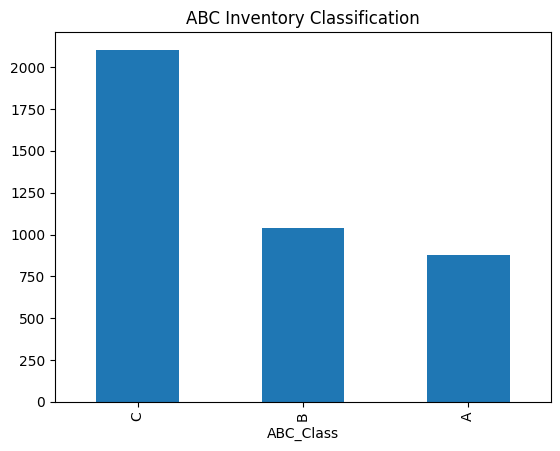

In [36]:
import matplotlib.pyplot as plt

abc_counts = (

    product_revenue[
        "ABC_Class"
    ]

    .value_counts()
)

abc_counts.plot(
    kind="bar"
)

plt.title(
    "ABC Inventory Classification"
)

plt.show()

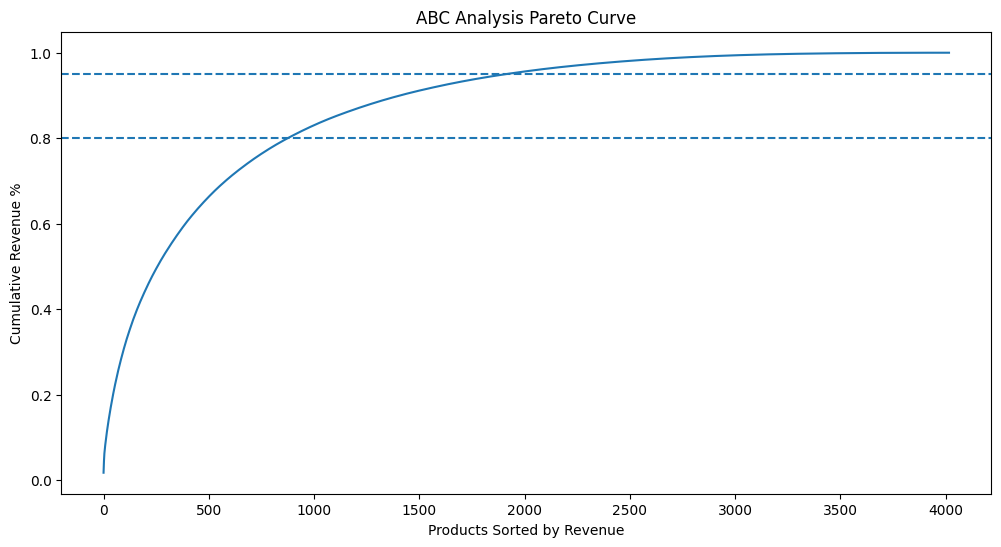

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    product_revenue["CumulativePct"].values
)

plt.axhline(
    y=0.80,
    linestyle="--"
)

plt.axhline(
    y=0.95,
    linestyle="--"
)

plt.title(
    "ABC Analysis Pareto Curve"
)

plt.ylabel(
    "Cumulative Revenue %"
)

plt.xlabel(
    "Products Sorted by Revenue"
)

plt.show()

In [38]:
product_revenue.to_csv(

    r"C:\Users\91991\Desktop\internships\AMDOX\data\processed\abc_inventory.csv",

    index=False
)

XYZ Analysis

In [39]:
import pandas as pd

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"]
)

df["Date"] = df["InvoiceDate"].dt.date

In [40]:
daily_product_sales = (

    df.groupby(
        ["StockCode", "Date"]
    )["Quantity"]

    .sum()

    .reset_index()
)

In [41]:
xyz_df = (

    daily_product_sales

    .groupby(
        "StockCode"
    )["Quantity"]

    .agg(
        ["mean", "std"]
    )

    .reset_index()
)

In [42]:
xyz_df["CV"] = (

    xyz_df["std"]

    / xyz_df["mean"]
)

In [43]:
xyz_df["CV"] = (
    xyz_df["CV"]
    .fillna(0)
)

In [45]:
print(df.shape)

(400916, 10)


In [46]:
def classify_xyz(cv):

    if cv <= 0.5:

        return "X"

    elif cv <= 1.0:

        return "Y"

    else:

        return "Z"

In [47]:
xyz_df["XYZ_Class"] = (

    xyz_df["CV"]

    .apply(
        classify_xyz
    )
)

In [48]:
print(

    xyz_df[
        "XYZ_Class"
    ]

    .value_counts()
)

XYZ_Class
Z    2415
Y    1119
X     483
Name: count, dtype: int64


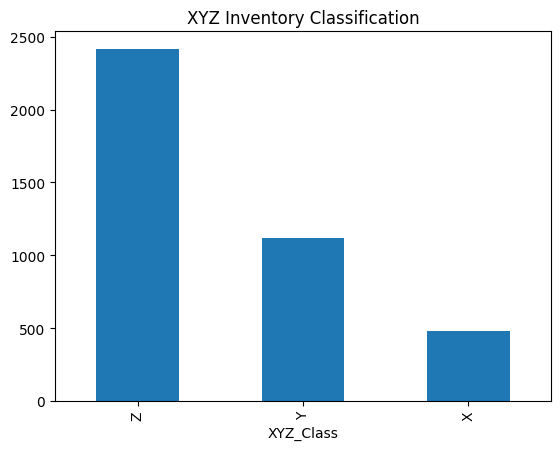

In [49]:
import matplotlib.pyplot as plt

xyz_df[
    "XYZ_Class"
].value_counts().plot(
    kind="bar"
)

plt.title(
    "XYZ Inventory Classification"
)

plt.show()

In [50]:
xyz_df.to_csv(

    r"C:\Users\91991\Desktop\internships\AMDOX\data\processed\xyz_inventory.csv",

    index=False
)

In [51]:
abc_xyz = product_revenue[
    [
        "StockCode",
        "ABC_Class"
    ]
].merge(

    xyz_df[
        [
            "StockCode",
            "XYZ_Class"
        ]
    ],

    on="StockCode"
)

In [52]:
abc_xyz["ABC_XYZ"] = (

    abc_xyz["ABC_Class"]

    +

    abc_xyz["XYZ_Class"]
)

In [53]:
print(

    abc_xyz[
        "ABC_XYZ"
    ]

    .value_counts()
)

ABC_XYZ
CZ    842
BZ    801
CY    793
AZ    772
CX    469
BY    228
AY     98
BX      9
AX      5
Name: count, dtype: int64


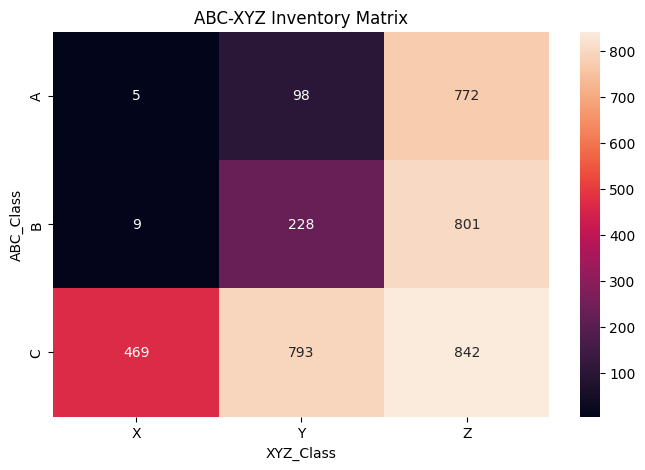

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

matrix = pd.crosstab(

    abc_xyz["ABC_Class"],

    abc_xyz["XYZ_Class"]
)

plt.figure(figsize=(8,5))

sns.heatmap(

    matrix,

    annot=True,

    fmt="d"
)

plt.title(
    "ABC-XYZ Inventory Matrix"
)

plt.show()

In [55]:
abc_xyz["Recommendation"] = abc_xyz["ABC_XYZ"].map({

    "AX": "Critical Stock",

    "AY": "Monitor Closely",

    "AZ": "High Safety Stock",

    "BX": "Normal Replenishment",

    "BY": "Periodic Review",

    "BZ": "Forecast Frequently",

    "CX": "Low Priority",

    "CY": "Reduce Inventory",

    "CZ": "Dead Stock Candidate"
})

In [56]:
abc_xyz.to_csv(

    r"C:\Users\91991\Desktop\internships\AMDOX\data\processed\inventory_intelligence.csv",

    index=False
)